In [1]:
import numpy as np
import pandas as pd

In [2]:
from sklearn.datasets import load_wine

In [3]:
wine = load_wine()

In [4]:
X = wine.data
y = wine.target

In [5]:
X.shape

(178, 13)

In [6]:
print(X[:,0])

[14.23 13.2  13.16 14.37 13.24 14.2  14.39 14.06 14.83 13.86 14.1  14.12
 13.75 14.75 14.38 13.63 14.3  13.83 14.19 13.64 14.06 12.93 13.71 12.85
 13.5  13.05 13.39 13.3  13.87 14.02 13.73 13.58 13.68 13.76 13.51 13.48
 13.28 13.05 13.07 14.22 13.56 13.41 13.88 13.24 13.05 14.21 14.38 13.9
 14.1  13.94 13.05 13.83 13.82 13.77 13.74 13.56 14.22 13.29 13.72 12.37
 12.33 12.64 13.67 12.37 12.17 12.37 13.11 12.37 13.34 12.21 12.29 13.86
 13.49 12.99 11.96 11.66 13.03 11.84 12.33 12.7  12.   12.72 12.08 13.05
 11.84 12.67 12.16 11.65 11.64 12.08 12.08 12.   12.69 12.29 11.62 12.47
 11.81 12.29 12.37 12.29 12.08 12.6  12.34 11.82 12.51 12.42 12.25 12.72
 12.22 11.61 11.46 12.52 11.76 11.41 12.08 11.03 11.82 12.42 12.77 12.
 11.45 11.56 12.42 13.05 11.87 12.07 12.43 11.79 12.37 12.04 12.86 12.88
 12.81 12.7  12.51 12.6  12.25 12.53 13.49 12.84 12.93 13.36 13.52 13.62
 12.25 13.16 13.88 12.87 13.32 13.08 13.5  12.79 13.11 13.23 12.58 13.17
 13.84 12.45 14.34 13.48 12.36 13.69 12.85 12.96 13.78

In [7]:
len(wine.feature_names)

13

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

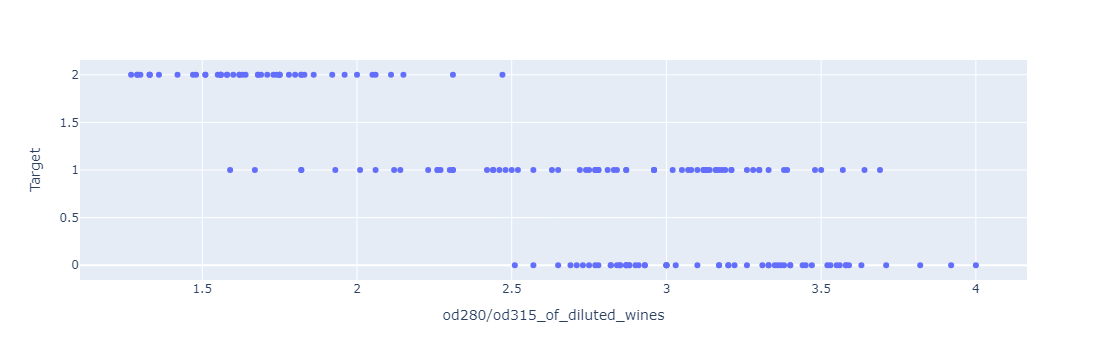

In [12]:
fig = px.scatter(x = X[:,11],y = y, labels={
        'x': wine.feature_names[11],
        'y': 'Target'
    })
fig.show()

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [13]:
X_train.shape

(142, 13)

In [14]:
from sklearn.preprocessing import StandardScaler

In [15]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
X_train

array([[ 1.66529275, -0.60840587,  1.21896194, ..., -1.65632857,
        -0.87940904, -0.24860607],
       [-0.54952506,  2.7515415 ,  1.00331502, ..., -0.58463272,
        -1.25462095, -0.72992237],
       [-0.74531007, -1.14354109, -0.93750727, ...,  0.35845962,
         0.2462267 , -0.24860607],
       ...,
       [ 1.714239  , -0.44172441,  0.06884503, ...,  1.04434496,
         0.56585166,  2.69572196],
       [-0.35374006, -0.7399965 , -0.36244882, ...,  0.01551695,
        -0.74044166, -0.79631083],
       [-0.78201975,  0.06709269,  0.35637426, ..., -0.67036839,
         1.09392769, -0.98551793]], shape=(142, 13))

In [17]:
from sklearn.decomposition import PCA

In [18]:
pca = PCA(n_components=5)

In [19]:
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [20]:
from sklearn.neighbors import KNeighborsClassifier

In [21]:
knn = KNeighborsClassifier()

In [22]:
knn.fit(X_train_trf, y_train)

KNeighborsClassifier()

In [23]:
y_pred = knn.predict(X_test_trf)

In [25]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9444444444444444

In [32]:
# transforming to a 2D coordinate system
pca = PCA(n_components=2)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

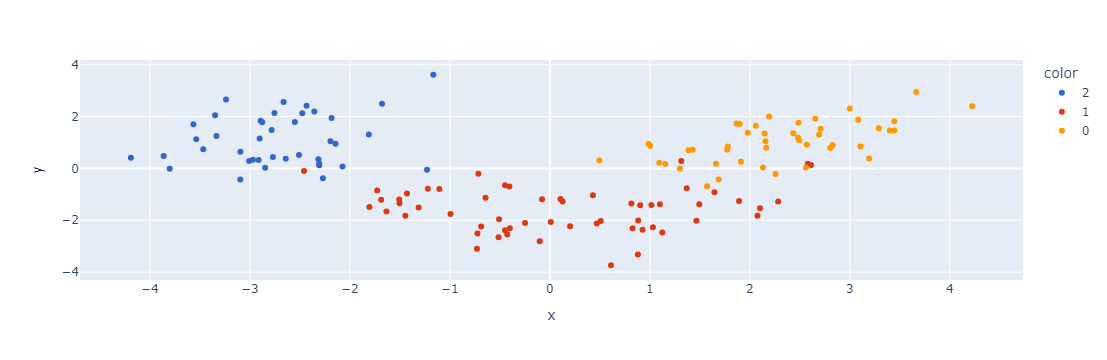

In [33]:
y_train_trf = y_train.astype(str)
fig = px.scatter(x=X_train_trf[:,0],
                 y=X_train_trf[:,1],
                 color=y_train_trf,
                 color_discrete_sequence=px.colors.qualitative.G10
                )
fig.show()

In [34]:
pca = PCA(n_components=3)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

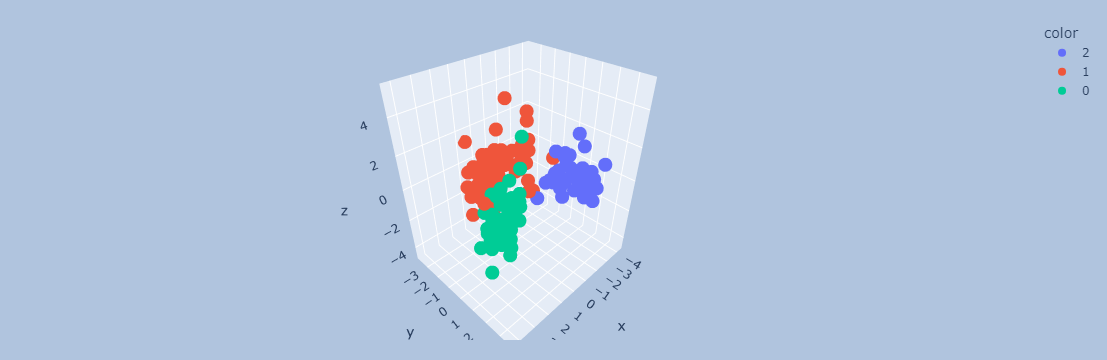

In [37]:
y_train_trf = y_train.astype(str)

fig = px.scatter_3d(
    x=X_train_trf[:, 0],
    y=X_train_trf[:, 1],
    z=X_train_trf[:, 2],
    color=y_train_trf
)

fig.update_layout(
    margin=dict(l=20, r=20, t=20, b=20),
    paper_bgcolor="LightSteelBlue"
)

fig.show()